In [2]:
import numpy as np
from matplotlib import pyplot as plt
import os
from os import path
import h5py

import sys
sys.path.insert(0, "./radiative_shock/")

from nlte_radiative_shock import NLTERadiativeShock

INFO:RadiativeShock:creating a RadiativeShock calculator...
INFO:RadiativeShock:gamma=1.66667
INFO:RadiativeShock:M0=2
INFO:RadiativeShock:P0=0.0001
INFO:RadiativeShock:downstream (unshocked, left) state: rho=5.45969e-13[g/cc] T=100[K]=8.617333e-06[keV] v=235470[cm/s]
INFO:RadiativeShock:upstream   (shocked, right)  state: rho=1.248126e-12[g/cc] T=207.757[K]=1.790311e-05[keV] v=103021.4[cm/s]
INFO:RadiativeShock:v_shock=34.7631[cm/s]
INFO:RadiativeShock:compression 2.28607
INFO:RadiativeShock:matter ideal gas (gamma=1.66667) dominated compression 2.28576
INFO:RadiativeShock:radiation ideal gas (gamma=4/3) dominated compression 2.91498
INFO:RadiativeShock:calculated mach=(v_shock-v_left)/cs_left=2 while given mach M0=2 err=2.22045e-16
INFO:NLTERadiativeShock:creating a NLTERadiativeShock calculator...


Precursor region
Relaxation region
Discontinuous case: embedded hydrodynamic shock


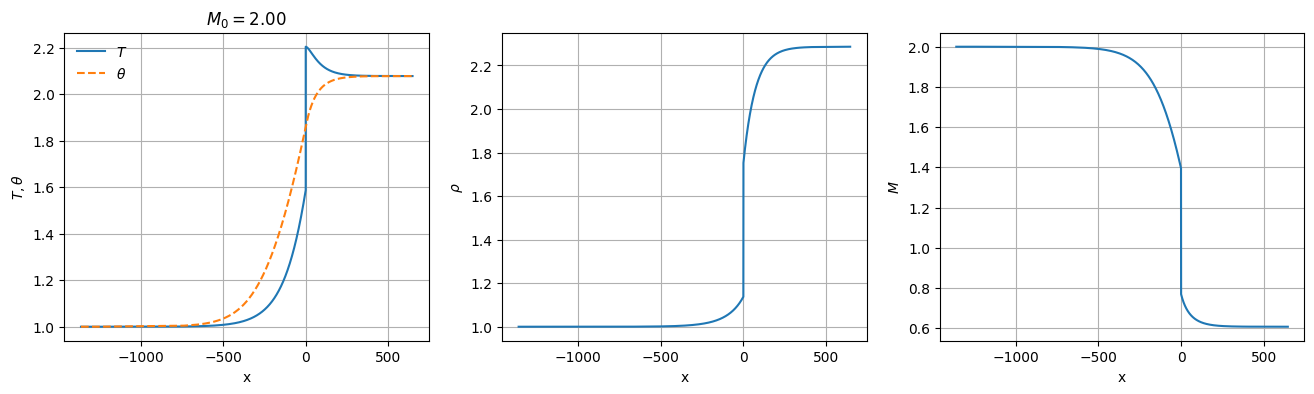

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


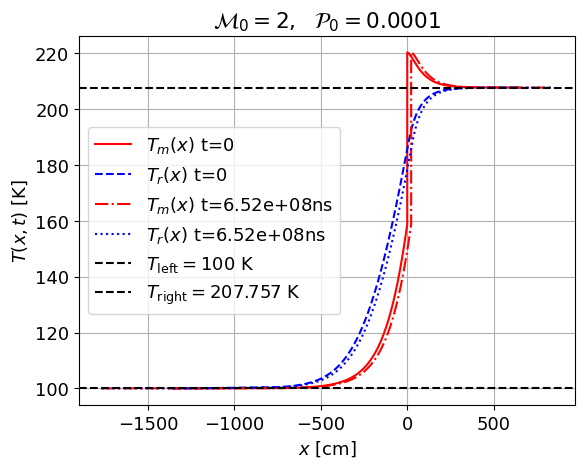

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


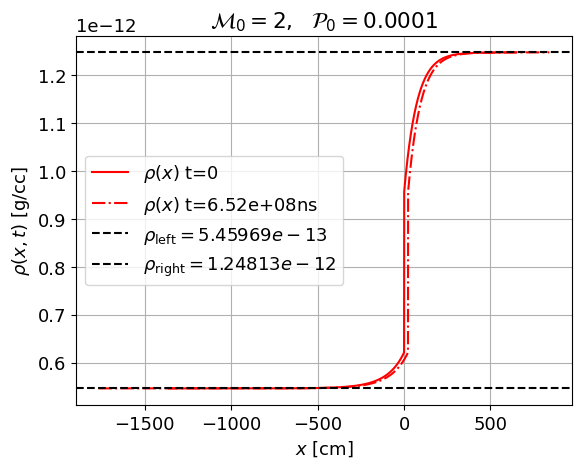

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


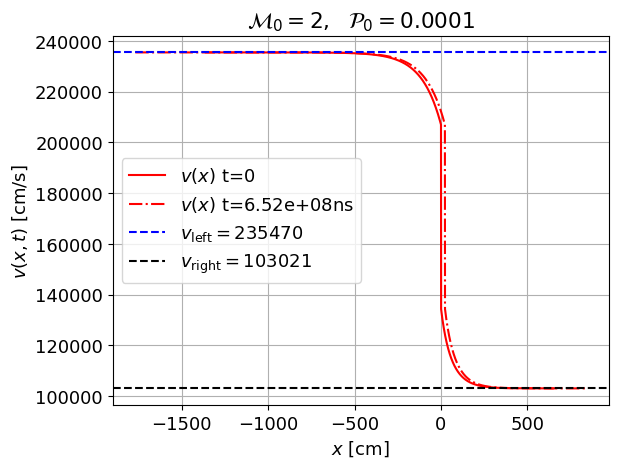

In [3]:
Navog = 6.02214076e23
k_boltz = 1.380649e-16
gas_constant = k_boltz*Navog
molar_mass_H = 1.
solver = NLTERadiativeShock(
    M0=2.,
    gamma=5./3.,
    sigma_ross=lambda T,rho:0.848903,
    sigma_abs=lambda T,rho:3.92664e-5,
    cv=gas_constant/(5./3.-1.)/molar_mass_H,
    rho_left=5.45969e-13,
    v_left=2.3547e5,
    T_left=100.,
    plot_dimensionless=True,
    eps_nlte_solver=0.5e-4,
).plot_profiles()

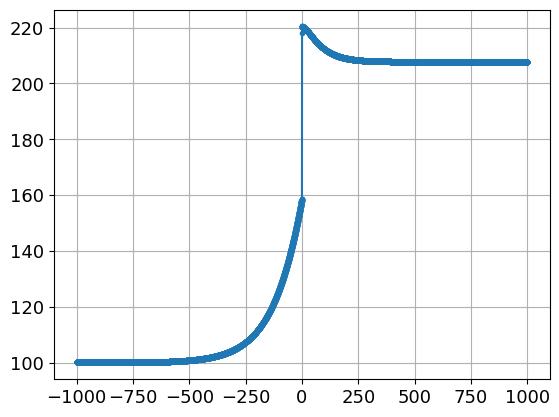

In [4]:
x = np.linspace(-1000, 1000, int(1e4))
sol = solver.solve_profiles(time=0.0, x=x)

plt.plot(x, sol["temperature"], '.-')
plt.grid()
plt.show()

In [15]:
output_files_path = "/home/itamarg/workspace/RICH/output/RadHydroMach2Multigroup"
path_to_initial_snap = path.join(output_files_path, f"Mach2_{0}.h5")

snaps = [file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))]
print(snaps)

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))])
num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())

['Mach2_0.h5', 'Mach2_100.h5', 'Mach2_200.h5', 'Mach2_300.h5', 'Mach2_400.h5', 'Mach2_500.h5', 'Mach2_600.h5', 'Mach2_700.h5', 'Mach2_800.h5', 'Mach2_900.h5', 'Mach2_1000.h5', 'Mach2_1100.h5', 'Mach2_1200.h5', 'Mach2_1300.h5', 'Mach2_1400.h5', 'Mach2_1500.h5', 'Mach2_1600.h5', 'Mach2_1700.h5', 'Mach2_1800.h5', 'Mach2_1900.h5', 'Mach2_2000.h5', 'Mach2_2100.h5', 'Mach2_2200.h5', 'Mach2_2300.h5', 'Mach2_2400.h5', 'Mach2_2500.h5', 'Mach2_2600.h5', 'Mach2_2700.h5', 'Mach2_2800.h5', 'Mach2_2900.h5', 'Mach2_3000.h5', 'Mach2_3100.h5', 'Mach2_3200.h5', 'Mach2_3300.h5', 'Mach2_3400.h5', 'Mach2_3500.h5', 'Mach2_3600.h5', 'Mach2_3700.h5', 'Mach2_3800.h5', 'Mach2_3900.h5', 'Mach2_4000.h5', 'Mach2_4100.h5', 'Mach2_4200.h5', 'Mach2_4300.h5', 'Mach2_4400.h5', 'Mach2_4500.h5', 'Mach2_4600.h5', 'Mach2_4700.h5', 'Mach2_4800.h5', 'Mach2_4900.h5', 'Mach2_5000.h5', 'Mach2_5100.h5', 'Mach2_5200.h5', 'Mach2_5300.h5', 'Mach2_5400.h5', 'Mach2_5500.h5', 'Mach2_5600.h5', 'Mach2_5700.h5', 'Mach2_5800.h5', 'Mach2_5

In [16]:
speed_of_light = 2.99792458e10
stefan_boltzman = 5.670374e-5
radiation_constant = 4 * stefan_boltzman / speed_of_light
boltzmann_constant = 1.380649e-16

ev = 1.602176634e-12
kev = 1e3*ev

kev_to_kelvin = kev / boltzmann_constant

G=num_groups
Emin = ev*1e-3
Emax = ev

energy_groups_boundary = np.geomspace(Emin, Emax, G+1)
energy_groups_boundary_kev = energy_groups_boundary / kev
energy_groups_width = np.diff(energy_groups_boundary, n=1)

In [17]:
Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"Mach2_{i*100}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

In [25]:
x = np.linspace(-1000, 2000, int(1e5))
sol = solver.solve_profiles(time=0.0, x=x)

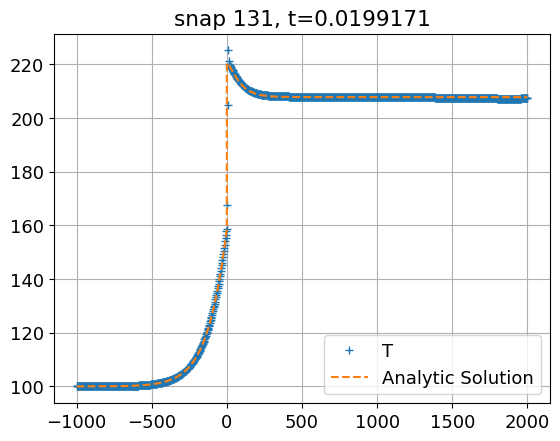

In [27]:
dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :], '+', label="T")
    plt.plot(x, sol['temperature'], '--', label="Analytic Solution")
    # plt.plot(CMx[i, :], Tr[i, :])

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    # plt.xlim(0, 3.)
    plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()
    